# EDA - Lily

In [13]:
#imports
#note train test split stratified and per patient
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
import os
import librosa as lb
import soundfile as sf

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from pathlib import Path
import pandas as pd
import librosa as lb
import soundfile as sf
from colorama import Fore, Style

# Demographics exploration

Demographic data - load and dataframe

  - Patient number
  - Age
  - Sex
  - Adult BMI (kg/m2)
  - Child Weight (kg)
  - Child Height (cm)


In [2]:
demographic_data = pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/demographic_info.txt',
                               sep=' ',
                               header=None,
                               names=["pid", "age", "sex", "adult_bmi", "child_weight", "child_height"])

print(demographic_data)

     pid    age  sex  adult_bmi  child_weight  child_height
0    101   3.00    F        NaN          19.0          99.0
1    102   0.75    F        NaN           9.8          73.0
2    103  70.00    F      33.00           NaN           NaN
3    104  70.00    F      28.47           NaN           NaN
4    105   7.00    F        NaN          32.0         135.0
..   ...    ...  ...        ...           ...           ...
121  222  60.00    M        NaN           NaN           NaN
122  223    NaN  NaN        NaN           NaN           NaN
123  224  10.00    F        NaN          32.3         143.0
124  225   0.83    M        NaN           7.8          74.0
125  226   4.00    M        NaN          16.7         103.0

[126 rows x 6 columns]


In [3]:
# Shape
print(f"Shape: {demographic_data.shape}")

# Column types
print("\nData types:")
print(demographic_data.dtypes)

# Null counts
print("\nNull counts:")
print(demographic_data.isnull().sum())

# Null percentages
print("\nNull percentages:")
print((demographic_data.isnull().sum() / len(demographic_data) * 100).round(2))

# Basic stats
print("\nDescriptive statistics:")
demographic_data.describe()

Shape: (126, 6)

Data types:
pid               int64
age             float64
sex              object
adult_bmi       float64
child_weight    float64
child_height    float64
dtype: object

Null counts:
pid              0
age              1
sex              1
adult_bmi       51
child_weight    82
child_height    84
dtype: int64

Null percentages:
pid              0.00
age              0.79
sex              0.79
adult_bmi       40.48
child_weight    65.08
child_height    66.67
dtype: float64

Descriptive statistics:


,pid,age,adult_bmi,child_weight,child_height
count,126.000000,125.00000,75.000000,44.000000,42.000000
mean,163.500000,42.99264,27.190000,21.361136,104.652381
std,36.517119,32.20907,5.372519,17.150885,30.793128
min,101.000000,0.25000,16.500000,7.140000,64.000000
25%,132.250000,4.00000,24.150000,11.755000,81.250000
50%,163.500000,60.00000,27.400000,15.100000,99.500000
75%,194.750000,71.00000,29.185000,24.325000,117.750000
max,226.000000,93.00000,53.500000,80.000000,183.000000


# Patient data exploration

Patient data - load and dataframe

  - Patient number
  - Disease


Patient data - load and dataframe

In [4]:
patient_data=pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv',
                         names=['pid','disease'])
patient_data.head()

,pid,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [5]:
patient_data.describe()

,pid
count,126.000000
mean,163.500000
std,36.517119
min,101.000000
25%,132.250000
50%,163.500000
75%,194.750000
max,226.000000


In [6]:
# Shape
print(f"Shape: {patient_data.shape}")

# Column types
print("\nData types:")
print(patient_data.dtypes)

# Null counts
print("\nNull counts:")
print(patient_data.isnull().sum())

# Null percentages
print("\nNull percentages:")
print((patient_data.isnull().sum() / len(patient_data) * 100).round(2))

# Basic stats
print("\nDescriptive statistics:")
patient_data.describe()

Shape: (126, 2)

Data types:
pid         int64
disease    object
dtype: object

Null counts:
pid        0
disease    0
dtype: int64

Null percentages:
pid        0.0
disease    0.0
dtype: float64

Descriptive statistics:


,pid
count,126.000000
mean,163.500000
std,36.517119
min,101.000000
25%,132.250000
50%,163.500000
75%,194.750000
max,226.000000


# Audio text file data exploration

Load and dataframes
  - Example txt file for an audio file
  - Audio txt files into one dataframe


Example of txt files of audio files

In [7]:
df=pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/160_1b3_Al_mc_AKGC417L.txt',sep='\t')
df.head()

,1.862,5.718,0,1
0,5.718,9.725,1,1
1,9.725,13.614,0,1
2,13.614,17.671,0,1
3,17.671,19.541,0,0


Load txt files into dataframe

In [8]:
path='/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'
files=[s.split('.')[0] for s in os.listdir(path) if '.txt' in s]
files[:5]

print(f'Number of audio files: {len(files)}')

Number of audio files: 920


In [9]:
#build df of info - row per breath cycle

def getFilenameInfo(file):
    parts = file.split('_')
    return {
        'patient_number': parts[0],
        'recording_index': parts[1],
        'chest_location': parts[2],
        'acquisition_mode': parts[3],
        'equipment': parts[4]
    }

files_data=[]
for file in files:
    data=pd.read_csv(path + file + '.txt',sep='\t',names=['start','end','crackles','weezels'])
    name_data=getFilenameInfo(file)
    data['pid']=name_data['patient_number']
    data['recording_index']=name_data['recording_index']
    data['chest_location']=name_data['chest_location']
    data['acquisition_mode']=name_data['acquisition_mode']
    data['equipment']=name_data['equipment']
    data['filename']=file
    files_data.append(data)

files_df=pd.concat(files_data)
files_df.reset_index()
files_df.head()

,start,end,crackles,weezels,pid,recording_index,chest_location,acquisition_mode,equipment,filename
0,0.022,0.364,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
1,0.364,2.436,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
2,2.436,4.636,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
3,4.636,6.793,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
4,6.793,8.750,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron


In [10]:
#join patient info with text files

patient_data.pid=patient_data.pid.astype('int32')
files_df.pid=files_df.pid.astype('int32')

audio_data=pd.merge(files_df,patient_data,on='pid')
audio_data.head()

,start,end,crackles,weezels,pid,recording_index,chest_location,acquisition_mode,equipment,filename,disease
0,0.022,0.364,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
1,0.364,2.436,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
2,2.436,4.636,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
3,4.636,6.793,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
4,6.793,8.750,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI


# Audio file data exploration

Load and dataframes
  - start and end of audio files

In [ ]:
#start and end of audiofiles - define parts of file that contain respiratory cycles

def getPureSample(raw_data,start,end,sr=22050):
    '''
    Takes a numpy array and spilts its using start and end args

    raw_data=numpy array of audio sample
    start=time
    end=time
    sr=sampling_rate
    mode=mono/stereo

    '''
    max_ind = len(raw_data)
    start_ind = min(int(start * sr), max_ind)
    end_ind = min(int(end * sr), max_ind)
    return raw_data[start_ind: end_ind]

<Axes: xlabel='None', ylabel='pid'>

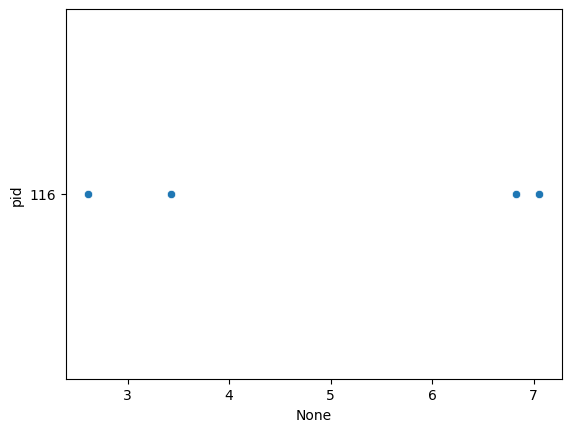

In [ ]:
sns.scatterplot(x=(data.end-data.start), y=data.pid)

<Axes: ylabel='None'>

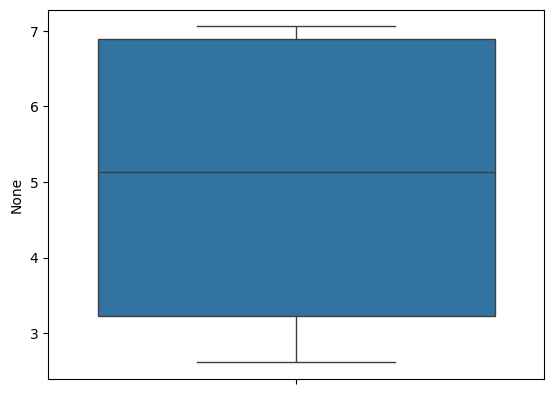

In [ ]:
sns.boxplot(y=(data.end-data.start))

In [ ]:
#iterate over dataset

for index,row in data.iterrows():
    print("Index ->",index)
    print("Data->\n",row)
    break

Index -> 0
Data->
 start                                0.022
end                                   3.45
crackles                                 0
weezels                                  0
pid                                    116
recording_index                        1b2
chest_location                          Pl
acquisition_mode                        sc
equipment                         Meditron
filename            116_1b2_Pl_sc_Meditron
Name: 0, dtype: object


In [ ]:
## example from kaggle notebook
i,c=0,0
for index,row in data.iterrows():
    maxLen=6
    start=row['start']
    end=row['end']
    filename=row['filename']

    #If len > maxLen , change it to maxLen
    if end-start>maxLen:
        end=start+maxLen

    audio_file_loc=path + filename + '.wav'

    if index > 0:
        #check if more cycles exits for same patient if so then add i to change filename
        if data.iloc[index-1]['filename']==filename:
            i+=1
        else:
            i=0
    filename= filename + '_' + str(i) + '.wav'

    save_path='processed_audio_files/' + filename
    c+=1

    audioArr,sampleRate=lb.load(audio_file_loc)
    pureSample=getPureSample(audioArr,start,end,sampleRate)

    #pad audio if pureSample len < max_len
    reqLen=6*sampleRate
    padded_data = lb.util.pad_center(pureSample, size=reqLen)

    sf.write(file=save_path,data=padded_data,samplerate=sampleRate)
print('Total Files Processed: ',c)

Total Files Processed:  4


# Preprocessing testing

In [1]:
import sys
import os

os.chdir('..')
sys.path.insert(0, '..')

from smart_stethoscope.interface.main import preprocessing

preprocessing()



✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...


/Users/lilyeastwood/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


(      crackles  wheezes                filename       age  sex  \
 0            0        0  148_1b1_Al_sc_Meditron -2.587543    1   
 1            0        0  148_1b1_Al_sc_Meditron -2.587543    1   
 2            0        0  148_1b1_Al_sc_Meditron -2.587543    1   
 3            0        0  148_1b1_Al_sc_Meditron -2.587543    1   
 4            0        0  148_1b1_Al_sc_Meditron -2.587543    1   
 ...        ...      ...                     ...       ...  ...   
 5801         1        0  130_2b3_Al_mc_AKGC417L  1.022203    0   
 5802         0        0  116_1b2_Pl_sc_Meditron -0.270176    1   
 5803         0        1  116_1b2_Pl_sc_Meditron -0.270176    1   
 5804         0        1  116_1b2_Pl_sc_Meditron -0.270176    1   
 5805         0        0  116_1b2_Pl_sc_Meditron -0.270176    1   
 
       chest_location_Al  chest_location_Ar  chest_location_Ll  \
 0                   1.0                0.0                0.0   
 1                   1.0                0.0                0.0